In [1]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import category_encoders as ce
import joblib
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from geopy.distance import geodesic
from sklearn.cluster import KMeans

# loading the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour column
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

# Extract the transaction month column
df['trans_month'] = df['trans_date_trans_time'].dt.month 

# Extract the day of the week
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)

# Create a new DataFrame with the filled values
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60

# Convert columns to datetime
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Calculate age at the time of transaction
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

# Create a new DataFrame to perform calculations
df_calc = pd.DataFrame(df)

# Sort by user (cc_num) to ensure correct order of transactions
df_calc = df_calc.sort_values(by=['cc_num'])

# Shift latitude and longitude of the previous merchant to get the previous transaction's coordinates
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)

# Fill null values with the current merchant's coordinates using assign method
df_calc = df_calc.assign(
    prev_merch_lat=df_calc['prev_merch_lat'].fillna(df_calc['merch_lat']),
    prev_merch_long=df_calc['prev_merch_long'].fillna(df_calc['merch_long'])
)

# Calculate the distance using the Haversine formula
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)

# Add the calculated distances back to the original DataFrame
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']

# Function to check if the transaction is during business hours
def is_business_hours(hour):
    return 1 if 9 <= hour <= 18 else 0

# Function to check if the transaction occurred on a weekend
def is_weekend(day):
    return 1 if day in ['Saturday', 'Sunday'] else 0

# Add business hours and weekend features
df['business_hours'] = df['trans_hour'].apply(is_business_hours)
df['weekend'] = df['trans_dayofweek'].apply(is_weekend)

# Add merchant location clusters
coords = df[['merch_lat', 'merch_long']].dropna().values
kmeans = KMeans(n_clusters=10, random_state=42)
df['merchant_cluster'] = kmeans.fit_predict(coords)

# Calculate the distance between customer city and merchant city if applicable
def calculate_customer_to_merchant_distance(row):
    customer_coords = (row['lat'], row['long'])
    merchant_coords = (row['merch_lat'], row['merch_long'])
    return geodesic(customer_coords, merchant_coords).kilometers

df['customer_to_merchant_distance'] = df.apply(calculate_customer_to_merchant_distance, axis=1)

# Calculate average transaction amount per credit card
df['avg_amt_per_cc'] = df.groupby('cc_num')['amt'].transform('mean')

# Calculate transaction frequency per day for the same credit card
df['trans_freq_per_day'] = df.groupby(['cc_num', df['transaction_time'].dt.date])['trans_date_trans_time'].transform('count')

# List of columns to drop
drop_cols = [
    'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
    'merch_lat', 'merch_long', 'dob'
]

# Dropping the columns from the DataFrame
df = df.drop(columns=drop_cols)

# splitting the train datasets into X and y
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# splitting the X and y into train and validate, using stratify split to ensure equal ratio of fraud and genuine 
# between the train and validate as the datasets is highly imbalanced
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# importing Winsorizer to cap the outliers using IQR
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch'] 
capper_iqr = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=outliers) 

# Capping outliers in X_train and X_val
X_train = capper_iqr.fit_transform(X_train) 
X_val = capper_iqr.transform(X_val)

# Function to apply WOE encoding and save encoders
def apply_woe_and_save_encoders(X_train, X_val, y_train, columns, encoder_filename):
    woe_encoders = []
    for col in columns:
        woe = ce.WOEEncoder(cols=[col])
        
        # Fit the encoder on the training data
        X_train_transformed = woe.fit_transform(X_train[[col]], y_train)
        
        # Transform the validation data
        X_val_transformed = woe.transform(X_val[[col]])
        
        # Add the transformed columns to the original DataFrames
        new_col_name = f"{col}_WOE"
        X_train[new_col_name] = X_train_transformed[col]
        X_val[new_col_name] = X_val_transformed[col]
        
        # Store the encoder
        woe_encoders.append(woe)

    # Save the list of encoders
    joblib.dump(woe_encoders, encoder_filename)
    
    return X_train, X_val

# Categorical columns to encode
columns_to_encode = ['state', 'job', 'trans_dayofweek', 'merchant', 'city']

# Apply WOE encoding to training and validation data and save encoders
encoder_filename = 'woe_encoders_newFeatures.joblib'
X_train_encoded, X_val_encoded = apply_woe_and_save_encoders(X_train, X_val, y_train, columns_to_encode, encoder_filename)

# Function to apply One-Hot Encoding
def apply_one_hot_encoding(X_train, X_val, columns):
    ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
    
    # Fit the encoder on the training data
    ohe.fit(X_train[columns])
    
    # Transform both training and validation data
    X_train_ohe = ohe.transform(X_train[columns])
    X_val_ohe = ohe.transform(X_val[columns])
    
    # Get new column names for the one-hot encoded columns
    ohe_columns = ohe.get_feature_names_out(columns)
    
    # Create DataFrames from the one-hot encoded arrays
    X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
    X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
    
    # Concatenate the new one-hot encoded columns to the original DataFrames
    X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
    X_val = pd.concat([X_val, X_val_ohe_df], axis=1)
    
    return X_train, X_val, ohe

# Columns to be one-hot encoded
ohe_columns = ['gender', 'category']

# Apply one-hot encoding to the training and validation datasets
X_train_encoded, X_val_encoded, ohe = apply_one_hot_encoding(X_train_encoded, X_val_encoded, ohe_columns)

# Save the One-Hot Encoder
joblib.dump(ohe, 'ohe_encoder_newFeatures.joblib')

# Columns to drop
columns_to_drop = ['category', 'gender', 'state', 'job', 'trans_dayofweek', 'city', 'merchant']

# Drop the specified columns from the training and validation sets
X_train_encoded = X_train_encoded.drop(columns=columns_to_drop)
X_val_encoded = X_val_encoded.drop(columns=columns_to_drop)

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

# Save the scaler
joblib.dump(scaler, 'standard_scaler_newFeatures.joblib')

# Convert the transformed data back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)

print(X_train_scaled_df.head())
print(X_val_scaled_df.head())


          cc_num       amt  city_pop  trans_hour  trans_month  \
332099 -0.319337  0.180830 -0.583030   -0.557908    -0.041317   
13250  -0.319222 -0.869159  1.886027    0.028767    -1.504594   
85129  -0.319337 -0.975061 -0.673943    0.175435    -1.211939   
325949 -0.315806 -0.410941 -0.698419    0.175435    -0.041317   
903602 -0.316688 -0.986347  0.286375    1.202115     1.714616   

        timedelta_last_trans  cust_age  distance_from_prev_merch  \
332099              0.124000 -1.179214                  0.082899   
13250               0.911195  0.084029                 -0.678084   
85129              -0.139840  0.371130                 -0.441697   
325949              1.110157  1.576953                 -0.649707   
903602             -0.671846 -0.145651                 -0.909529   

        business_hours   weekend  ...  category_grocery_pos  \
332099        1.103458 -0.731162  ...              -0.32469   
13250         1.103458 -0.731162  ...              -0.32469   
85129      

In [4]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib
from geopy.distance import geodesic
from sklearn.cluster import KMeans

# Load the unseen dataset
df = pd.read_csv('../../data/raw/Fraudtest.csv')

# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour, month, and day of the week
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift and fill NaN values
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60

# Convert columns to datetime and calculate age at the time of transaction
df['dob'] = pd.to_datetime(df['dob'])
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

# Calculate distance from previous merchant
df_calc = pd.DataFrame(df)
df_calc = df_calc.sort_values(by=['cc_num'])
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)
df_calc = df_calc.assign(
    prev_merch_lat=df_calc['prev_merch_lat'].fillna(df_calc['merch_lat']),
    prev_merch_long=df_calc['prev_merch_long'].fillna(df_calc['merch_long'])
)
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']

# Function to check if the transaction is during business hours
def is_business_hours(hour):
    return 1 if 9 <= hour <= 18 else 0

# Function to check if the transaction occurred on a weekend
def is_weekend(day):
    return 1 if day in ['Saturday', 'Sunday'] else 0

# Add business hours and weekend features
df['business_hours'] = df['trans_hour'].apply(is_business_hours)
df['weekend'] = df['trans_dayofweek'].apply(is_weekend)

# Add merchant location clusters
coords = df[['merch_lat', 'merch_long']].dropna().values
kmeans = KMeans(n_clusters=10, random_state=42)
df['merchant_cluster'] = kmeans.fit_predict(coords)

# Calculate the distance between customer city and merchant city if applicable
def calculate_customer_to_merchant_distance(row):
    customer_coords = (row['lat'], row['long'])
    merchant_coords = (row['merch_lat'], row['merch_long'])
    return geodesic(customer_coords, merchant_coords).kilometers

df['customer_to_merchant_distance'] = df.apply(calculate_customer_to_merchant_distance, axis=1)

# Calculate average transaction amount per credit card
df['avg_amt_per_cc'] = df.groupby('cc_num')['amt'].transform('mean')

# Calculate transaction frequency per day for the same credit card
df['trans_freq_per_day'] = df.groupby(['cc_num', df['transaction_time'].dt.date])['trans_date_trans_time'].transform('count')

# Drop redundant columns
drop_cols = [
    'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
    'merch_lat', 'merch_long', 'dob'
]
df = df.drop(columns=drop_cols)

# Separate features and target variable
X_unseen = df.drop(columns=["is_fraud"])
y_unseen = df["is_fraud"]

# Load the saved WOE encoders
woe_encoders = joblib.load('woe_encoders_newFeatures.joblib')

# Apply WOE Encoding
def apply_woe(X, woe_columns, woe_encoders):
    for col, encoder in zip(woe_columns, woe_encoders):
        X_transformed = encoder.transform(X[[col]])
        new_col_name = f"{col}_WOE"
        X[new_col_name] = X_transformed[col]
    return X

woe_columns = ['state', 'job', 'trans_dayofweek', 'merchant', 'city']
X_unseen = apply_woe(X_unseen, woe_columns, woe_encoders)

# Load the One-Hot Encoder and apply to unseen data
ohe = joblib.load('ohe_encoder_newFeatures.joblib')
unseen_encoded = ohe.transform(X_unseen[['gender', 'category']])

# Create a DataFrame with the encoded columns
unseen_encoded_df = pd.DataFrame(unseen_encoded, columns=ohe.get_feature_names_out(['gender', 'category']), index=X_unseen.index)

# Drop the original 'gender' and 'category' columns and concatenate the new encoded columns
X_unseen = pd.concat([X_unseen.drop(columns=['gender', 'category']), unseen_encoded_df], axis=1)

# Drop the original categorical columns
columns_to_drop = [ 'state', 'job', 'trans_dayofweek', 'city', 'merchant']
X_unseen = X_unseen.drop(columns=columns_to_drop)

# Load the StandardScaler and apply to unseen data
scaler = joblib.load('standard_scaler_newFeatures.joblib')
X_unseen_scaled = scaler.transform(X_unseen)
X_unseen_scaled_df = pd.DataFrame(X_unseen_scaled, columns=X_unseen.columns, index=X_unseen.index)

# Display a sample of the final DataFrame for unseen data
print("\nFinal Unseen DataFrame Sample:")
print(X_unseen_scaled_df.head())



Final Unseen DataFrame Sample:
       cc_num       amt  city_pop  trans_hour  trans_month  \
157  -0.31936  1.256024 -0.622172    0.028767    -0.041317   
741  -0.31936  0.388119 -0.622172    0.468772    -0.041317   
3047 -0.31936  0.138506 -0.622172   -0.851245    -0.041317   
4351 -0.31936  0.561549 -0.622172    0.322104    -0.041317   
7695 -0.31936  1.695431 -0.622172   -0.117902    -0.041317   

      timedelta_last_trans  cust_age  distance_from_prev_merch  \
157               2.126590 -0.662433                  1.710655   
741              -0.557227 -0.662433                  1.613446   
3047              1.027977 -0.662433                  1.794508   
4351             -0.007920 -0.662433                  1.736781   
7695              1.728667 -0.662433                  1.718503   

      business_hours   weekend  ...  category_grocery_pos  \
157         1.103458  1.367685  ...              -0.32469   
741         1.103458  1.367685  ...              -0.32469   
3047       -0.9

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9961696953493931
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.61      0.94      0.74      2252

    accuracy                           1.00    389003
   macro avg       0.80      0.97      0.87    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[385393   1358]
 [   132   2120]]
Validation ROC AUC Score: 0.9983142187725734
Validation PR AUC Score: 0.9388635628672392


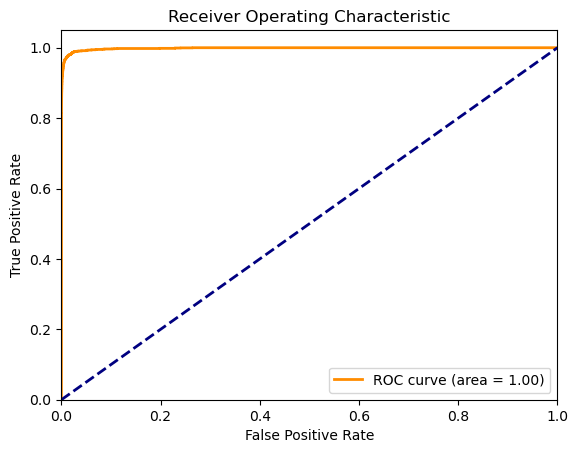

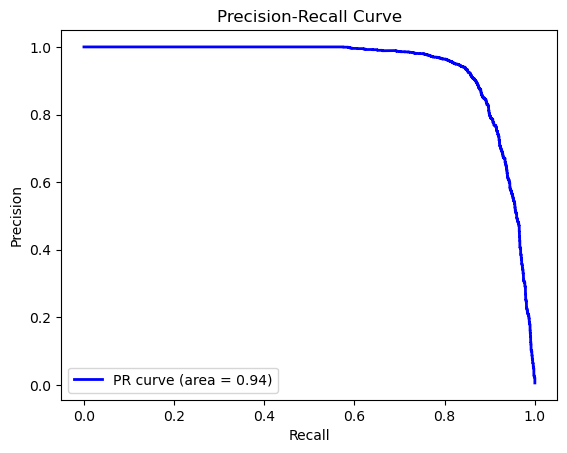

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9932519852659347
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.24      0.35      0.29      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.67      0.64    555719
weighted avg       0.99      0.99      0.99    555719

Unseen Data Confusion Matrix:
 [[551214   2360]
 [  1390    755]]
Unseen Data ROC AUC Score: 0.9316636989204704
Unseen Data PR AUC Score: 0.3162029003828451


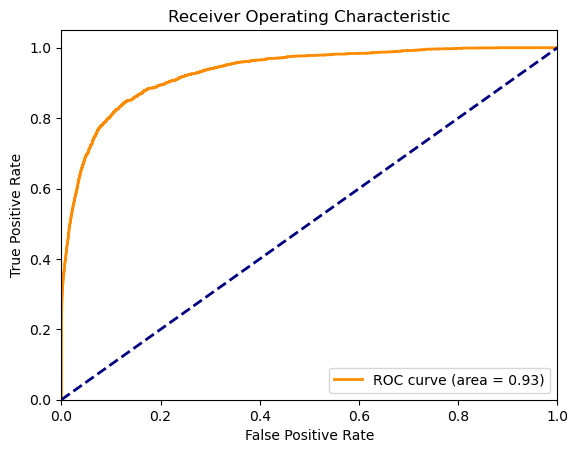

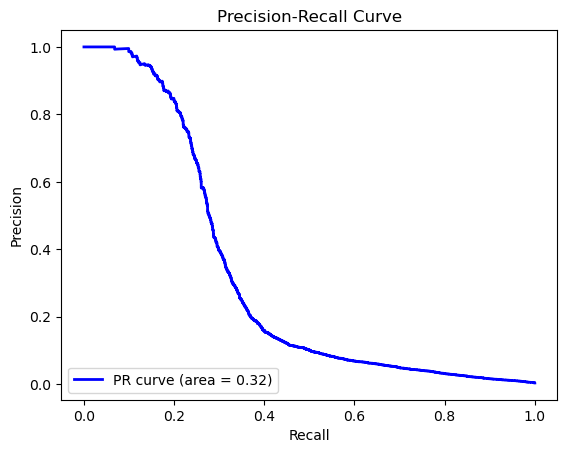

In [16]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import numpy as np

# Step 1: Initial Training
def train_model(scale_pos_weight, X_train_scaled_df, y_train):
    model = XGBClassifier(scale_pos_weight=scale_pos_weight)
    model.fit(X_train_scaled_df, y_train)
    return model

# Step 2: Evaluate the Model
def evaluate_model(model, X_val_scaled_df, y_val):
    y_pred = model.predict(X_val_scaled_df)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    return precision, recall, f1

# Step 3: Adjust scale_pos_weight
def adjust_scale_pos_weight(precision, recall, f1, scale_pos_weight):
    # Example heuristic for adjustment
    if recall < 0.5:  # If recall is low, minority class is under-predicted
        scale_pos_weight *= 1.2  # Increase weight
    elif recall > 0.8 and precision < 0.5:  # If recall is high but precision is low
        scale_pos_weight *= 0.8  # Decrease weight
    return scale_pos_weight

# Example adaptive loop
scale_pos_weight = 1

for i in range(5):  # A few iterations of adjustment
    model = train_model(scale_pos_weight, X_train_scaled_df, y_train)
    precision, recall, f1 = evaluate_model(model, X_val_scaled_df, y_val)
    
    print(f"Iteration {i+1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    # Adjust the scale_pos_weight based on evaluation
    scale_pos_weight = adjust_scale_pos_weight(precision, recall, f1, scale_pos_weight)

# Final model training with the optimized scale_pos_weight
final_model = train_model(scale_pos_weight, X_train_scaled_df, y_train)


Iteration 1 - Precision: 0.9604, Recall: 0.8193, F1: 0.8843
Iteration 2 - Precision: 0.9604, Recall: 0.8193, F1: 0.8843
Iteration 3 - Precision: 0.9604, Recall: 0.8193, F1: 0.8843
Iteration 4 - Precision: 0.9604, Recall: 0.8193, F1: 0.8843
Iteration 5 - Precision: 0.9604, Recall: 0.8193, F1: 0.8843


Validation Accuracy: 0.9987583643313804
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.96      0.82      0.88      2252

    accuracy                           1.00    389003
   macro avg       0.98      0.91      0.94    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[386675     76]
 [   407   1845]]
Validation ROC AUC Score: 0.9986210015207393
Validation PR AUC Score: 0.9439932116208515


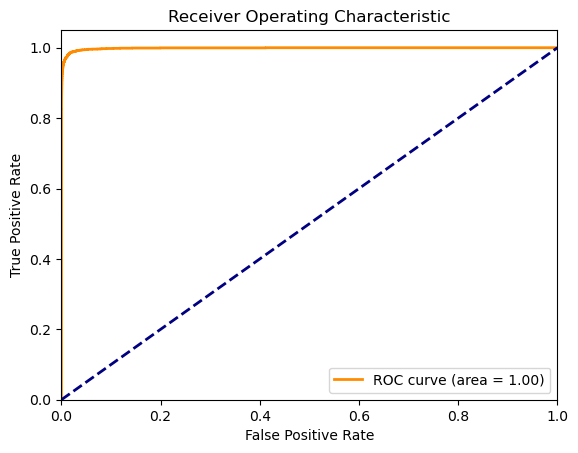

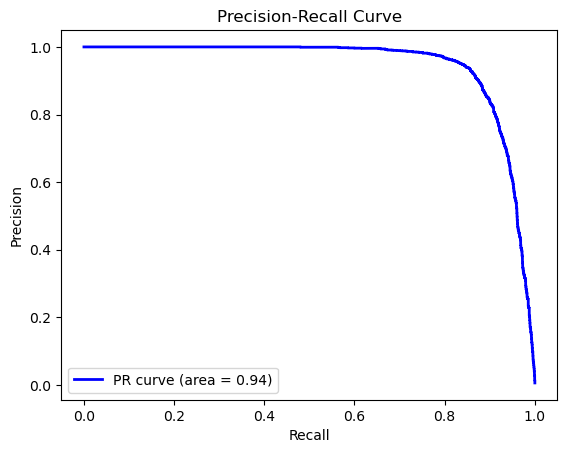

In [20]:
# Make predictions on the validation data
y_val_pred = final_model.predict(X_val_scaled_df)
y_val_pred_proba = final_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9967087682803719
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.69      0.26      0.38      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.63      0.69    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[553323    251]
 [  1578    567]]
Unseen Data ROC AUC Score: 0.9232466651563285
Unseen Data PR AUC Score: 0.34605398036373686


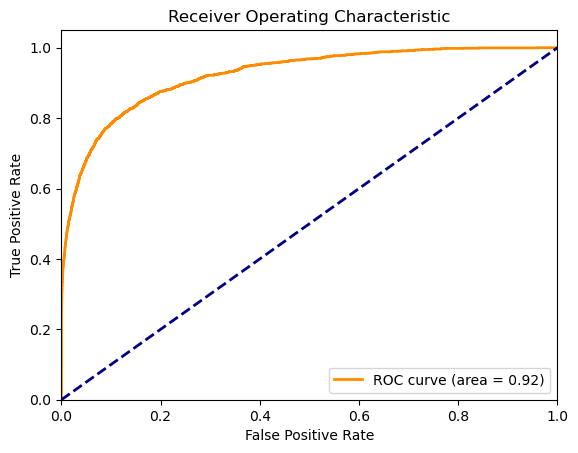

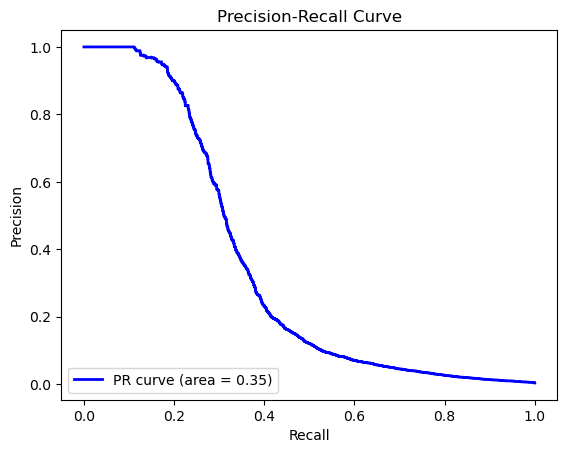

In [21]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = final_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = final_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy with Risk-Based Thresholding: 0.9965684095739034
Unseen Data Classification Report with Risk-Based Thresholding:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.62      0.28      0.39      2145

    accuracy                           1.00    555719
   macro avg       0.81      0.64      0.69    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix with Risk-Based Thresholding:
 [[553202    372]
 [  1535    610]]
Unseen Data ROC AUC Score with Risk-Based Thresholding: 0.9232466651563285
Unseen Data PR AUC Score with Risk-Based Thresholding: 0.34605398036373686


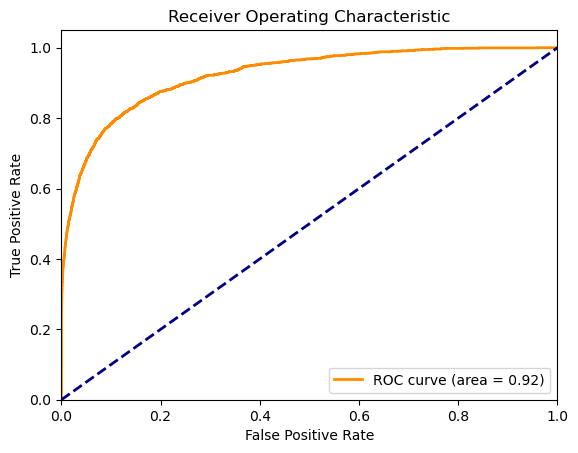

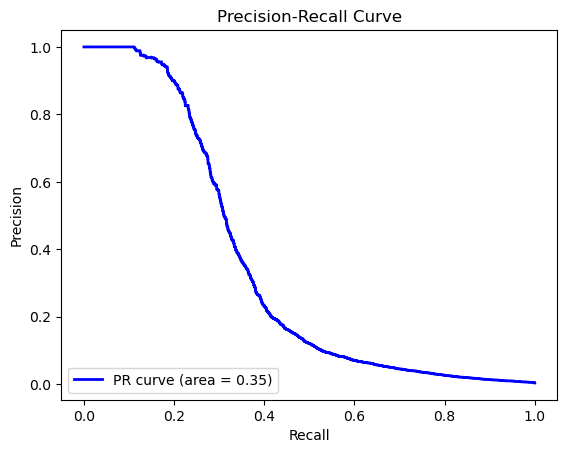

In [22]:
# Predict probabilities on the unseen data
y_unseen_pred_proba_1 = final_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Rescale the standardized amt back to its original scale using the same mean and std used during scaling
amt_mean = X_train['amt'].mean()
amt_std = X_train['amt'].std()

def risk_based_threshold(proba, standardized_amt, base_threshold=0.5):
    # Rescale amt back to its original scale
    original_amt = standardized_amt * amt_std + amt_mean
    adjusted_threshold = base_threshold - 0.1 * np.log1p(original_amt / 100)
    return proba > adjusted_threshold

# Apply risk-based threshold to make final predictions
transaction_amounts_std = X_unseen_scaled_df['amt'].values
y_unseen_pred_risk_based = [
    1 if risk_based_threshold(proba, amt_std) else 0
    for proba, amt_std in zip(y_unseen_pred_proba_1, transaction_amounts_std)
]

# Convert to NumPy array for consistency
y_unseen_pred_risk_based = np.array(y_unseen_pred_risk_based)

# Evaluate the model on the unseen data with risk-based thresholding
print("Unseen Data Accuracy with Risk-Based Thresholding:", accuracy_score(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Classification Report with Risk-Based Thresholding:\n", classification_report(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data Confusion Matrix with Risk-Based Thresholding:\n", confusion_matrix(y_unseen, y_unseen_pred_risk_based))
print("Unseen Data ROC AUC Score with Risk-Based Thresholding:", roc_auc_score(y_unseen, y_unseen_pred_proba_1))
print("Unseen Data PR AUC Score with Risk-Based Thresholding:", average_precision_score(y_unseen, y_unseen_pred_proba_1))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba_1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba_1)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

<Figure size 5000x8000 with 0 Axes>

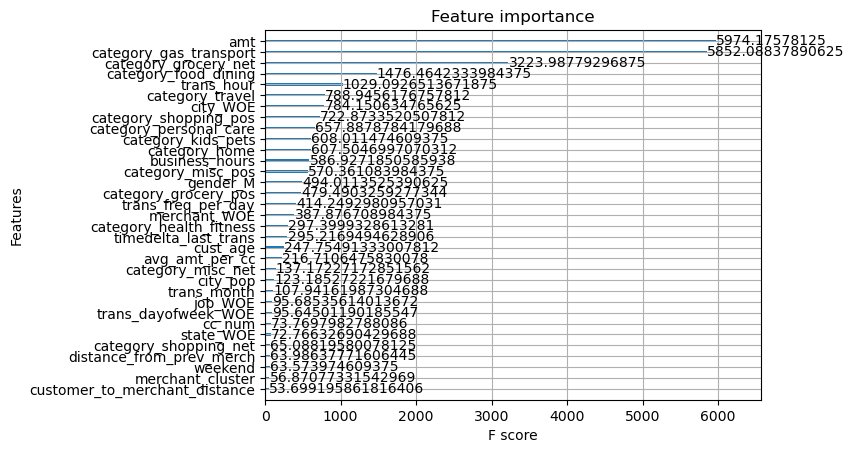

In [7]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(50, 80))  # Adjust the width and height as needed

# Plot the feature importance
plot_importance(xgb_model, importance_type='gain')

# Show the plot
plt.show()

In [39]:
%%time
# Import necessary libraries
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from collections import Counter
import numpy as np
import pandas as pd

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = np.sqrt(counter[0] / counter[1])
print(f"Scale Pos Weight: {scale_pos_weight:.3f}")

# Instantiate XGBoost model with scale_pos_weight
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')

# Number of features to select
n_features_to_select = 20  # Adjust this based on your needs

# Instantiate RFE with the XGBoost model
rfe = RFE(estimator=xgb_model, n_features_to_select=n_features_to_select, step=1)

# Fit RFE on the training data
rfe.fit(X_train_scaled_df, y_train)

# Transform the training, validation, and unseen datasets
X_train_rfe = rfe.transform(X_train_scaled_df)
X_val_rfe = rfe.transform(X_val_scaled_df)
X_unseen_rfe = rfe.transform(X_unseen_scaled_df)

# Optionally, you can create DataFrames with the selected features
X_train_rfe_df = pd.DataFrame(X_train_rfe, columns=X_train_scaled_df.columns[rfe.support_], index=X_train_scaled_df.index)
X_val_rfe_df = pd.DataFrame(X_val_rfe, columns=X_val_scaled_df.columns[rfe.support_], index=X_val_scaled_df.index)
X_unseen_rfe_df = pd.DataFrame(X_unseen_rfe, columns=X_unseen_scaled_df.columns[rfe.support_], index=X_unseen_scaled_df.index)

# Display the selected features
print("Selected features after RFE:")
print(X_train_rfe_df.columns)


Scale Pos Weight: 13.106
Selected features after RFE:
Index(['amt', 'trans_hour', 'timedelta_last_trans', 'cust_age',
       'business_hours', 'avg_amt_per_cc', 'trans_freq_per_day',
       'merchant_WOE', 'city_WOE', 'gender_M', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_home', 'category_kids_pets',
       'category_misc_pos', 'category_personal_care', 'category_shopping_pos',
       'category_travel'],
      dtype='object')
CPU times: total: 4min 42s
Wall time: 21.8 s


Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9942185535844197
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.50      0.94      0.65      2252

    accuracy                           0.99    389003
   macro avg       0.75      0.97      0.82    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384640   2111]
 [   138   2114]]
Validation ROC AUC Score: 0.9979660014404373
Validation PR AUC Score: 0.9148488203865045


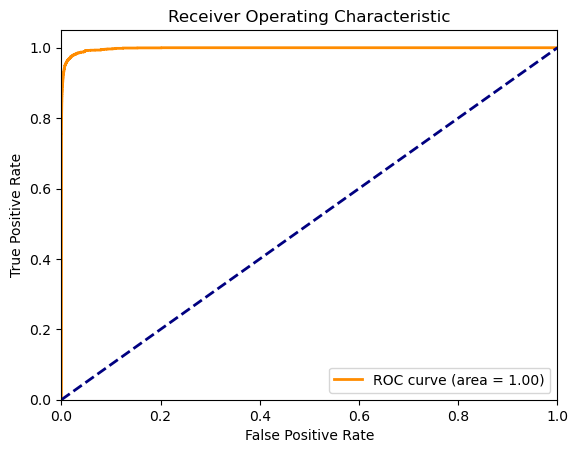

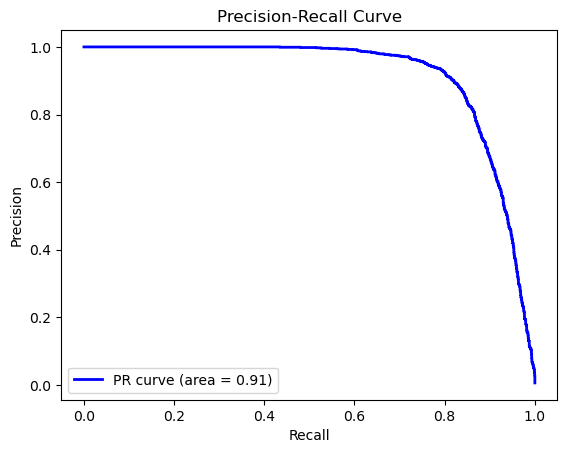

In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=171, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_rfe_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9910854226686509
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.18      0.37      0.24      2145

    accuracy                           0.99    555719
   macro avg       0.59      0.68      0.62    555719
weighted avg       0.99      0.99      0.99    555719

Unseen Data Confusion Matrix:
 [[549966   3608]
 [  1346    799]]
Unseen Data ROC AUC Score: 0.9335417210862951
Unseen Data PR AUC Score: 0.30831514702385077


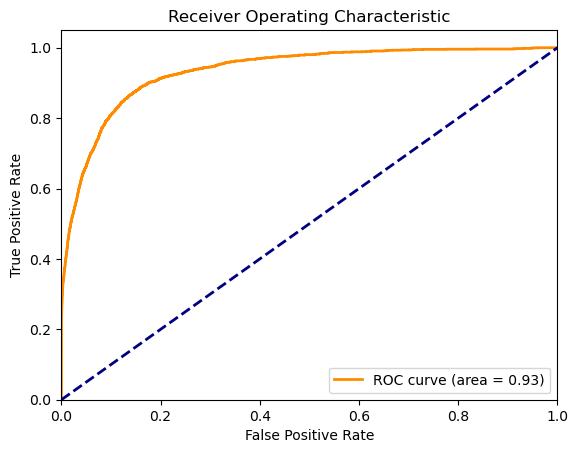

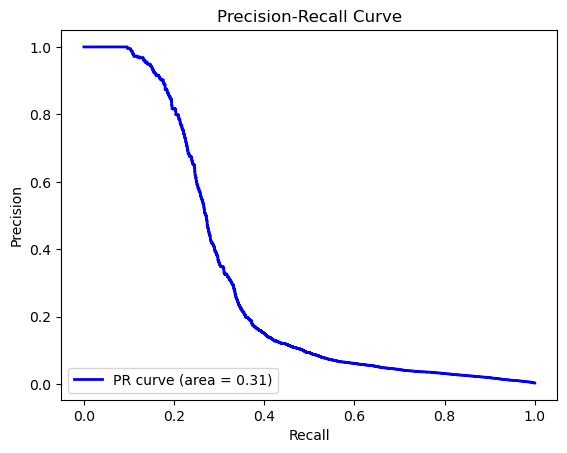

In [44]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = xgb_model.predict(X_unseen_rfe_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Validation Accuracy: 0.9834
Validation Precision: 0.2530
Validation Recall: 0.9560
Validation F1 Score: 0.4001
Validation ROC-AUC: 0.9963
Validation PR AUC: 0.8719
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    386751
           1       0.25      0.96      0.40      2252

    accuracy                           0.98    389003
   macro avg       0.63      0.97      0.70    389003
weighted avg       1.00      0.98      0.99    389003

Validation Confusion Matrix:
[[380395   6356]
 [    99   2153]]
True Positives (TP): 2153
False Positives (FP): 6356
True Negatives (TN): 380395
False Negatives (FN): 99


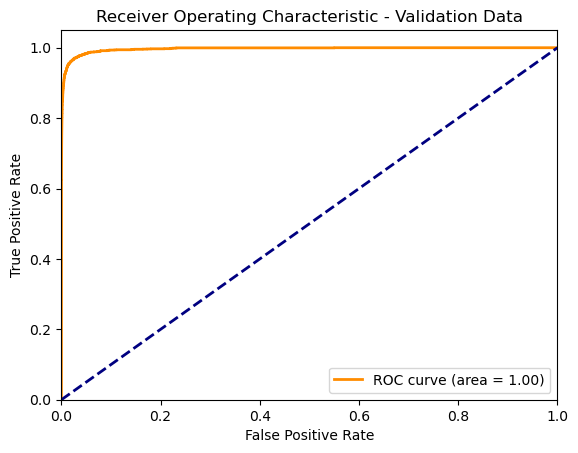

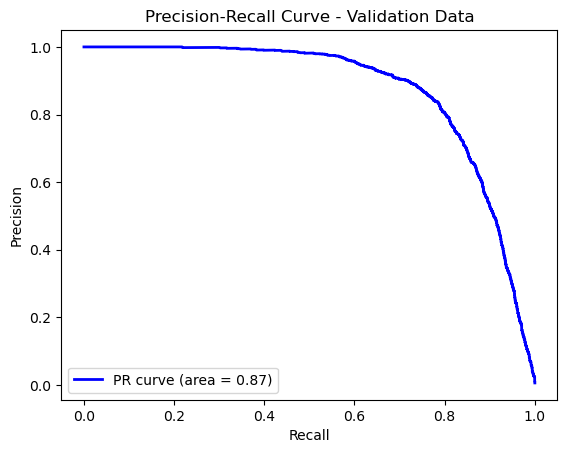

CPU times: total: 49.2 s
Wall time: 9.11 s


In [47]:
%%time
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_rfe_df, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_rfe_df)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_rfe_df)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

# Plot ROC Curve for validation data
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for validation data
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()



Unseen Data Accuracy: 0.9792
Unseen Data Precision: 0.0699
Unseen Data Recall: 0.3562
Unseen Data F1 Score: 0.1169
Unseen Data ROC-AUC: 0.8962
Unseen Data PR AUC: 0.1840
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.07      0.36      0.12      2145

    accuracy                           0.98    555719
   macro avg       0.53      0.67      0.55    555719
weighted avg       0.99      0.98      0.99    555719

Unseen Data Confusion Matrix:
[[543412  10162]
 [  1381    764]]
True Positives (TP): 764
False Positives (FP): 10162
True Negatives (TN): 543412
False Negatives (FN): 1381


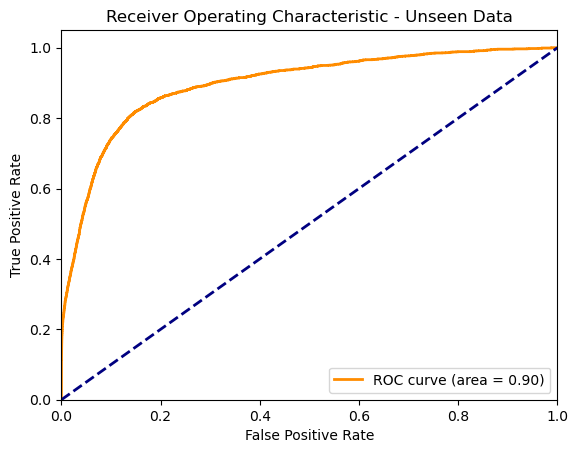

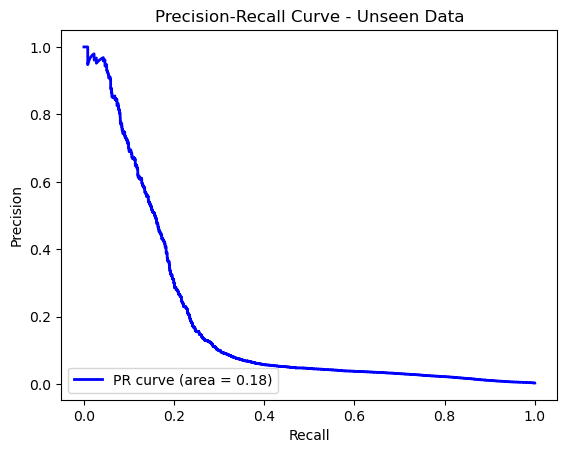

In [48]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_rfe_df)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_rfe_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for unseen data
precision_unseen, recall_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_unseen, precision_unseen)
plt.figure()
plt.plot(recall_unseen, precision_unseen, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


In [11]:
%whos

Variable                                  Type                      Data/Info
-----------------------------------------------------------------------------
Counter                                   type                      <class 'collections.Counter'>
KMeans                                    ABCMeta                   <class 'sklearn.cluster._kmeans.KMeans'>
OneHotEncoder                             type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
RandomForestClassifier                    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler                            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold                           ABCMeta                   <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
Winsorizer                                type                      <class 'feature_engine.ou<...>s.winsorizer.Winsorizer'>
X                

Validation Accuracy: 0.9905
Validation Precision: 0.3743
Validation Recall: 0.9423
Validation F1 Score: 0.5357
Validation ROC-AUC: 0.9968
Validation PR AUC: 0.9001
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.37      0.94      0.54      2252

    accuracy                           0.99    389003
   macro avg       0.69      0.97      0.77    389003
weighted avg       1.00      0.99      0.99    389003

Validation Confusion Matrix:
[[383203   3548]
 [   130   2122]]
True Positives (TP): 2122
False Positives (FP): 3548
True Negatives (TN): 383203
False Negatives (FN): 130


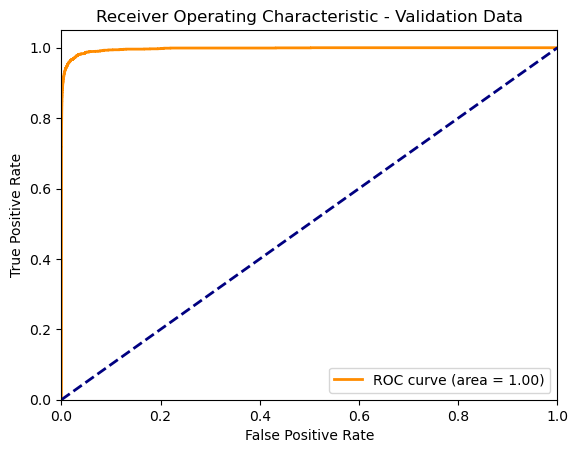

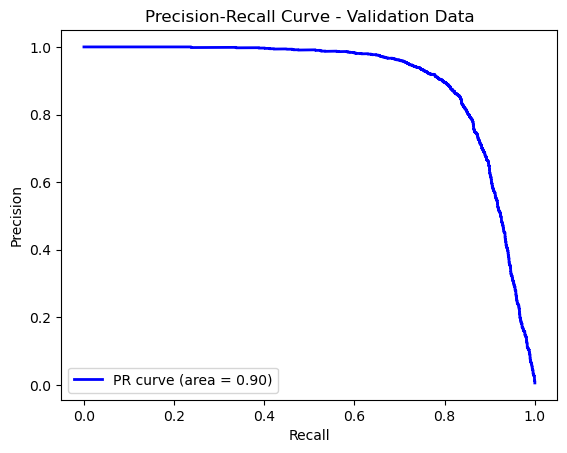

In [13]:
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

best_xgb_model_ADASYN = xgb_model
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled_df, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_scaled_df)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_scaled_df)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

# Plot ROC Curve for validation data
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for validation data
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()



Unseen Data Accuracy: 0.9866
Unseen Data Precision: 0.1043
Unseen Data Recall: 0.3254
Unseen Data F1 Score: 0.1580
Unseen Data ROC-AUC: 0.8905
Unseen Data PR AUC: 0.2067
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.10      0.33      0.16      2145

    accuracy                           0.99    555719
   macro avg       0.55      0.66      0.58    555719
weighted avg       0.99      0.99      0.99    555719

Unseen Data Confusion Matrix:
[[547580   5994]
 [  1447    698]]
True Positives (TP): 698
False Positives (FP): 5994
True Negatives (TN): 547580
False Negatives (FN): 1447


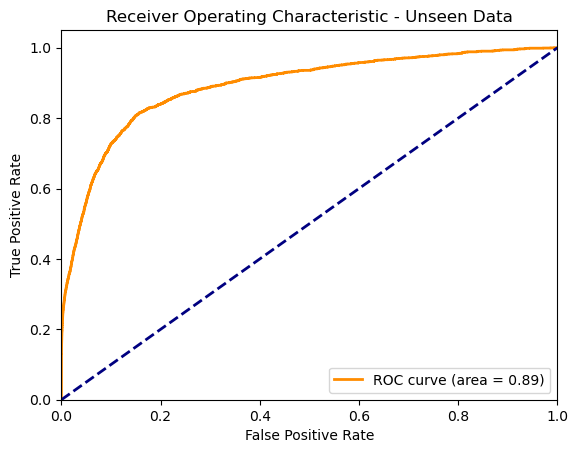

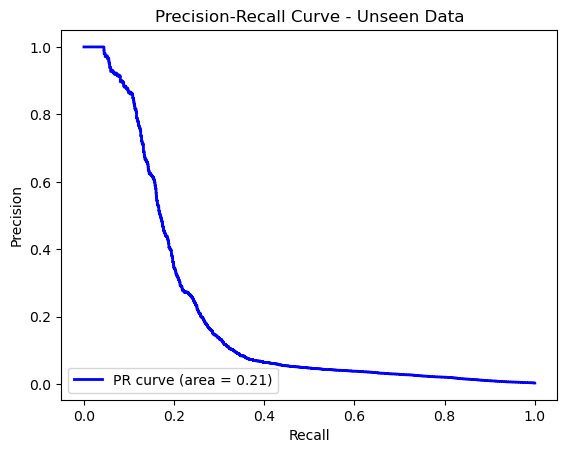

In [14]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_scaled_df)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve for unseen data
precision_unseen, recall_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_unseen, precision_unseen)
plt.figure()
plt.plot(recall_unseen, precision_unseen, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


In [29]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

ValueError: feature_names mismatch: ['amt', 'trans_hour', 'trans_freq_per_day', 'city_WOE', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_home', 'category_misc_pos', 'category_travel'] ['cc_num', 'amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans', 'cust_age', 'distance_from_prev_merch', 'business_hours', 'weekend', 'merchant_cluster', 'customer_to_merchant_distance', 'avg_amt_per_cc', 'trans_freq_per_day', 'state_WOE', 'job_WOE', 'trans_dayofweek_WOE', 'merchant_WOE', 'city_WOE', 'gender_M', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']
training data did not have the following fields: customer_to_merchant_distance, distance_from_prev_merch, business_hours, cust_age, cc_num, cate

*************

Validation Accuracy: 0.9978354922712678
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.98      0.64      0.77      2252

    accuracy                           1.00    389003
   macro avg       0.99      0.82      0.89    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[386725     26]
 [   816   1436]]
Validation ROC AUC Score: 0.988383501856402
Validation PR AUC Score: 0.8914256424733347


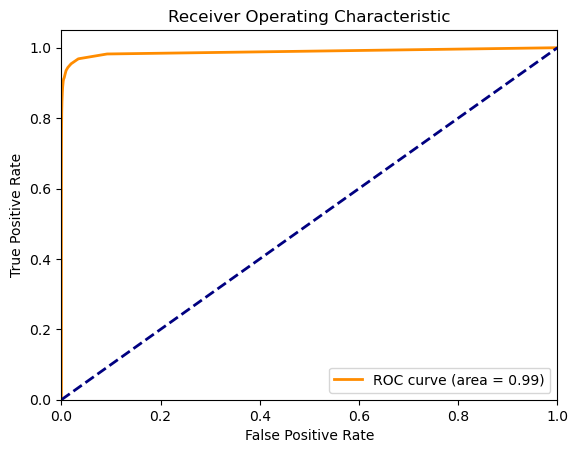

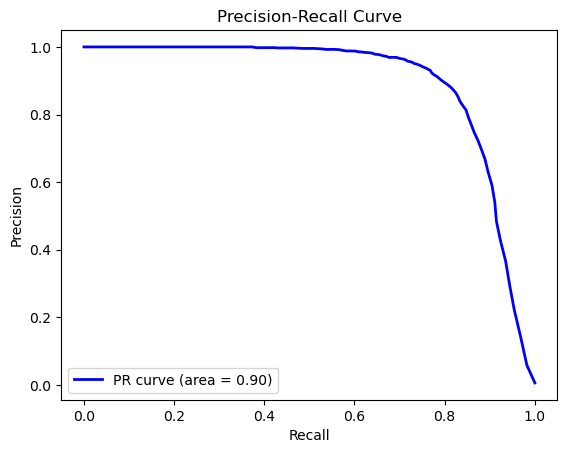

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = rf_model.predict(X_val_scaled_df)
y_val_pred_proba = rf_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy (Initial): 0.9972324142237354
Unseen Data Classification Report (Initial):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.85      0.34      0.49      2145

    accuracy                           1.00    555719
   macro avg       0.92      0.67      0.74    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Initial):
 [[553446    128]
 [  1410    735]]
Unseen Data ROC AUC Score (Initial): 0.9642999919244829
Unseen Data PR AUC Score (Initial): 0.6308949229935676


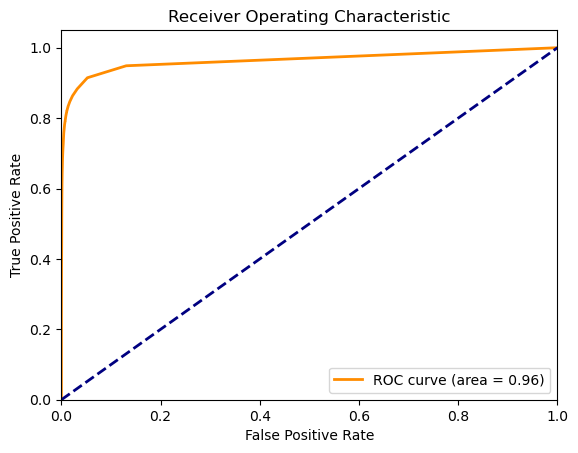

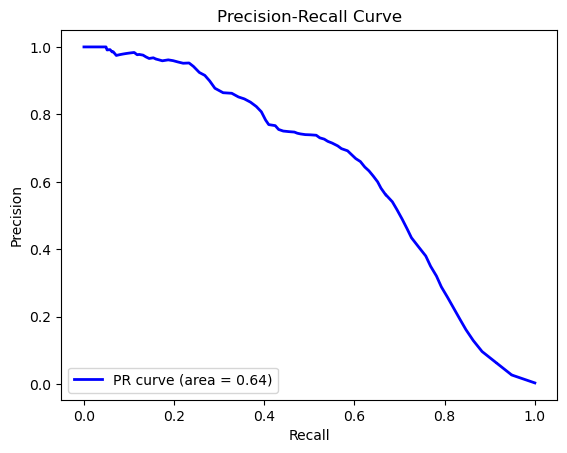

In [9]:
# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train_scaled_df, y_train)
# Make predictions on the unseen data with the initial model (before hyperparameter tuning)
y_unseen_pred_initial = rf_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba_initial = rf_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy (Initial):", accuracy_score(y_unseen, y_unseen_pred_initial))
print("Unseen Data Classification Report (Initial):\n", classification_report(y_unseen, y_unseen_pred_initial))
print("Unseen Data Confusion Matrix (Initial):\n", confusion_matrix(y_unseen, y_unseen_pred_initial))
print("Unseen Data ROC AUC Score (Initial):", roc_auc_score(y_unseen, y_unseen_pred_proba_initial))
print("Unseen Data PR AUC Score (Initial):", average_precision_score(y_unseen, y_unseen_pred_proba_initial))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba_initial)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba_initial)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

In [10]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(rf_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


KeyboardInterrupt: 

In [ ]:
%%time
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import joblib

# Ensure the custom cross-validator is defined
strat_k_fold = StratifiedKFold(n_splits=5)

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 20, 40, 50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize the HalvingRandomSearchCV
halving_search = HalvingRandomSearchCV(
    rf_model,
    param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=20,
    verbose=1,  # Add verbosity for debugging
    random_state=42
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    halving_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", halving_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", halving_search.best_score_)


In [ ]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = halving_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = halving_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()